# Credit Card Client Default Payment Prediction Using Classifiers

### Assignment for UBC's Applied Machine Learning course

*by Sabrina Lou and Nandini Rana*

<!-- BEGIN QUESTION -->

## Imports

In [2]:
from hashlib import sha1

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap

from sklearn.dummy import DummyClassifier
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.feature_selection import RFECV
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

from sklearn.compose import make_column_transformer
from sklearn.model_selection import (
    GridSearchCV,
    RandomizedSearchCV, 
    cross_val_score,
    cross_validate,
    train_test_split,
)
from sklearn.preprocessing import (
    OneHotEncoder,
    OrdinalEncoder,
    StandardScaler
)
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.tree import DecisionTreeClassifier

<!-- BEGIN QUESTION -->

### Classification problem using Default of Credit Card Clients Dataset

[Default of Credit Card Clients Dataset](https://www.kaggle.com/uciml/default-of-credit-card-clients-dataset).

In this data set, there are 30,000 examples and 24 features, and the goal is to estimate whether a person will default (fail to pay) their credit card bills; this column is labeled "default.payment.next.month" in the data. The rest of the columns can be used as features. You may take some ideas and compare your results with [the associated research paper](https://www.sciencedirect.com/science/article/pii/S0957417407006719), which is available through [the UBC library](https://www.library.ubc.ca/). 

<div class="alert alert-info">
    
**Your tasks:**

1. Review the available datasets and choose the one you find most interesting. It may help to read through the dataset documentation on Kaggle before deciding.
2. Once you've selected a dataset, take time to understand the problem it represents and the meaning of each feature. Use the Kaggle documentation to guide you.
3. Download the dataset and load it into a pandas DataFrame.
4. Write a few sentences summarizing your initial thoughts about the problem and the dataset.
   
</div>

**4. To predict whether or not a client will default payment, we have a few features that describe the demographic of the client, and features that describe their credit card payment and billing history. Intuitively, these features all could be relevant to the prediction and would help train a good classifier. It is also interesting to see how strongly the demographic features influence the prediction compared to the credit card history.**

In [7]:
clients_df = pd.read_csv("data/UCI_Credit_Card.csv")
# clients_df.head()
clients_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ID                          30000 non-null  int64  
 1   LIMIT_BAL                   30000 non-null  float64
 2   SEX                         30000 non-null  int64  
 3   EDUCATION                   30000 non-null  int64  
 4   MARRIAGE                    30000 non-null  int64  
 5   AGE                         30000 non-null  int64  
 6   PAY_0                       30000 non-null  int64  
 7   PAY_2                       30000 non-null  int64  
 8   PAY_3                       30000 non-null  int64  
 9   PAY_4                       30000 non-null  int64  
 10  PAY_5                       30000 non-null  int64  
 11  PAY_6                       30000 non-null  int64  
 12  BILL_AMT1                   30000 non-null  float64
 13  BILL_AMT2                   300

<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 2. Data splitting
<hr>
rubric={points:2}

<div class="alert alert-info">
    
**Your tasks:**

1. Split the data into train (70%) and test (30%) portions with `random_state=123`.

> If your computer cannot handle training on 70% training data, make the test split bigger.

</div>

In [4]:
train_df, test_df = train_test_split(
    clients_df, test_size=0.3, random_state=123
)

<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 3. EDA
<hr>

<div class="alert alert-info">

**Your tasks:**

1. **Perform exploratory data analysis (EDA)**: Conduct an initial exploration of the training set to better understand its characteristics.

2. **Summarize and visualize the data**: Include at least **two summary statistics** and **two visualizations** that you find informative. For each, write **one sentence** explaining what insight it provides.

3. **Record your observations**: Summarize your **initial observations** about the dataset based on your EDA.

4. **Select evaluation metrics**: Choose one or more **appropriate metrics** for assessing model performance and briefly justify your choice.

</div>

### 1. EDA code below

### 2. Summary Statistics and Visualization Insights

#### Non-default payment clients (over the last 6 months):

1. Average monthly outstanding bill (bill statement - payment) amount for non-default payment clients: **$39606.97**.

    - **Insight:** Non-default payment clients have a lower mean "outstanding bill amount" than default payment clients, which is the amount they owe to the bank.

2. Average balance limit (credit given): **$178297.94**.

    - **Insight:** Non-default payment clients have a higher mean balance limit/credit than default payment clients, meaning they have higher limits to their spending.


#### Default payment clients (over the last 6 months):

1. Average outstanding bill amount (bill statement - payment) for default payment clients: **$40086.01.**

    - **Insight:** Default payment clients have a slightly higher mean "outstanding bill amount" than default payment clients, meaning they owe more to the bank than non-default payment clients.

2. Average balance limit (credit given): **$131633.46.**

    - **Insight:** Default payment clients have a much lower mean balance limit/credit than non-default payment clients, meaning they have more restricted spending.


#### Visalization A. Monthly payment vs bill statement for default clients scatterplot
- **Insight:** In the cluster of points that show high bill statements and low payment amounts, it is primarily August and September 2005 data points, while there are many high payments made with low bill statements across all months (likely repayment efforts).

#### Visalization B. Balance limit vs Age of client scatterplot
- **Insight:** Most default payment clients are lower in age and have lower balance limits.

### 3. Observations

Default payment clients on average have higher monthly outstanding bill amounts (bill statement - payment amount) that they owe to the bank. Default payment clients have lower balance limits on average. The average age of clients in the dataset are 35, with a large cluster of the default payment clients centred around that age. There are 4688 default payment clients, making up 22% of the dataset.

### 4. Evaluation Metrics

Based on the 22% positive class (default payment) rate, we can balance the risk of False Positive and False Negative classifications in our model since these errors have relatively similar impacts. Therefore, we should look at the **prediction accuracy, F1 score, precision, and recall**.

In [5]:
#1 looking at dataset column and feature sizes
print("Shape/dimension:" + str(train_df.shape))
print("Unique IDs: " + str(train_df['ID'].unique().shape[0]))
print("Column feature data types:")
print(str(train_df.dtypes))

Shape/dimension:(21000, 25)
Unique IDs: 21000
Column feature data types:
ID                              int64
LIMIT_BAL                     float64
SEX                             int64
EDUCATION                       int64
MARRIAGE                        int64
AGE                             int64
PAY_0                           int64
PAY_2                           int64
PAY_3                           int64
PAY_4                           int64
PAY_5                           int64
PAY_6                           int64
BILL_AMT1                     float64
BILL_AMT2                     float64
BILL_AMT3                     float64
BILL_AMT4                     float64
BILL_AMT5                     float64
BILL_AMT6                     float64
PAY_AMT1                      float64
PAY_AMT2                      float64
PAY_AMT3                      float64
PAY_AMT4                      float64
PAY_AMT5                      float64
PAY_AMT6                      float64
default.payment

In [6]:
# 1 output values
value_counts = train_df["default.payment.next.month"].value_counts()
print("Value counts of " + str(value_counts))
print(value_counts[1] / (value_counts[1] + value_counts[0]))

Value counts of default.payment.next.month
0    16312
1     4688
Name: count, dtype: int64
0.22323809523809524


In [7]:
# 1 summary statistics of bill and payment amounts
print(train_df.iloc[:, 1:].describe())

            LIMIT_BAL           SEX     EDUCATION      MARRIAGE           AGE  \
count    21000.000000  21000.000000  21000.000000  21000.000000  21000.000000   
mean    167880.651429      1.600762      1.852143      1.554000     35.500810   
std     130202.682167      0.489753      0.792961      0.521675      9.212644   
min      10000.000000      1.000000      0.000000      0.000000     21.000000   
25%      50000.000000      1.000000      1.000000      1.000000     28.000000   
50%     140000.000000      2.000000      2.000000      2.000000     34.000000   
75%     240000.000000      2.000000      2.000000      2.000000     41.000000   
max    1000000.000000      2.000000      6.000000      3.000000     79.000000   

              PAY_0         PAY_2         PAY_3         PAY_4         PAY_5  \
count  21000.000000  21000.000000  21000.000000  21000.000000  21000.000000   
mean      -0.015429     -0.137095     -0.171619     -0.225238     -0.264429   
std        1.120465      1.194506

In [8]:
# 2 Summary statistics
non_def_df = train_df.loc[train_df["default.payment.next.month"] == 0]
avg_limit = non_def_df["LIMIT_BAL"].mean()
avg_bill = ((non_def_df["BILL_AMT6"] + non_def_df["BILL_AMT5"] +non_def_df["BILL_AMT4"] +non_def_df["BILL_AMT3"] +non_def_df["BILL_AMT2"] +non_def_df["BILL_AMT1"]) / 6).mean()
avg_pay = ((non_def_df["PAY_AMT6"] + non_def_df["PAY_AMT5"] +non_def_df["PAY_AMT4"] +non_def_df["PAY_AMT3"] +non_def_df["PAY_AMT2"] +non_def_df["PAY_AMT1"]) / 6).mean()
avg_pay_diff = avg_bill - avg_pay
print("Average bill statement amount over 6 months for non-default payment clients: " + str(avg_bill))
print("Average payment amount over 6 months for non-default payment clients: " + str(avg_pay))
print("Average outstanding bill amount over 6 months for non-default payment clients: " + str(avg_pay_diff))
print("Average balance limit: " + str(avg_limit))

default_df = train_df.loc[train_df["default.payment.next.month"] == 1]
def_avg_limit = default_df["LIMIT_BAL"].mean()
def_avg_bill = ((default_df["BILL_AMT6"] + default_df["BILL_AMT5"] +default_df["BILL_AMT4"] +default_df["BILL_AMT3"] +default_df["BILL_AMT2"] +default_df["BILL_AMT1"]) / 6).mean()
def_avg_pay = ((default_df["PAY_AMT6"] + default_df["PAY_AMT5"] +default_df["PAY_AMT4"] +default_df["PAY_AMT3"] +default_df["PAY_AMT2"] +default_df["PAY_AMT1"]) / 6).mean()
def_avg_pay_diff = def_avg_bill - def_avg_pay
print("Average bill statement amount over 6 months for default payment clients: " + str(def_avg_bill))
print("Average payment amount over 6 months for default payment clients: " + str(def_avg_pay))
print("Average outstanding bill amount over 6 months for default payment clients: " + str(def_avg_pay_diff))
print("Average balance limit: " + str(def_avg_limit))


Average bill statement amount over 6 months for non-default payment clients: 45452.30280366193
Average payment amount over 6 months for non-default payment clients: 5845.332219633808
Average outstanding bill amount over 6 months for non-default payment clients: 39606.970584028124
Average balance limit: 178297.94016674842
Average bill statement amount over 6 months for default payment clients: 43371.80421643913
Average payment amount over 6 months for default payment clients: 3285.796466154721
Average outstanding bill amount over 6 months for default payment clients: 40086.00775028441
Average balance limit: 131633.46416382253


<Axes: title={'center': 'Figure 3a. Monthly payment vs bill statement for default clients'}, xlabel='Bill amount (NT)', ylabel='Payment amount (NT)'>

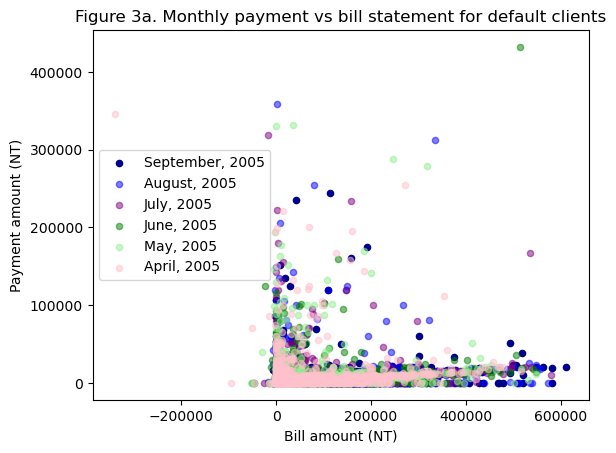

In [9]:
# 2a Visualization
default_ax = default_df.plot(kind='scatter', x='BILL_AMT1', y='PAY_AMT1', color="DarkBlue", label='September, 2005')
default_df.plot(kind='scatter', x='BILL_AMT2', y='PAY_AMT2', color="Blue", label='August, 2005', alpha=0.5, ax=default_ax)
default_df.plot(kind='scatter', x='BILL_AMT3', y='PAY_AMT3', color="Purple", label='July, 2005', alpha=0.5, ax=default_ax)
default_df.plot(kind='scatter', x='BILL_AMT4', y='PAY_AMT4', color="Green", label='June, 2005', alpha=0.5, ax=default_ax)
default_df.plot(kind='scatter', x='BILL_AMT5', y='PAY_AMT5', color="LightGreen", label='May, 2005', alpha=0.5, ax=default_ax)
default_df.plot(kind='scatter', x='BILL_AMT6', y='PAY_AMT6', color="Pink", label='April, 2005', xlabel="Bill amount (NT)", ylabel="Payment amount (NT)", 
                title="Figure 3a. Monthly payment vs bill statement for default clients", alpha=0.5, ax=default_ax)

<Axes: title={'center': 'Figure 3b. Balance limit vs Age of client'}, xlabel='Age', ylabel='Balance limit (NT)'>

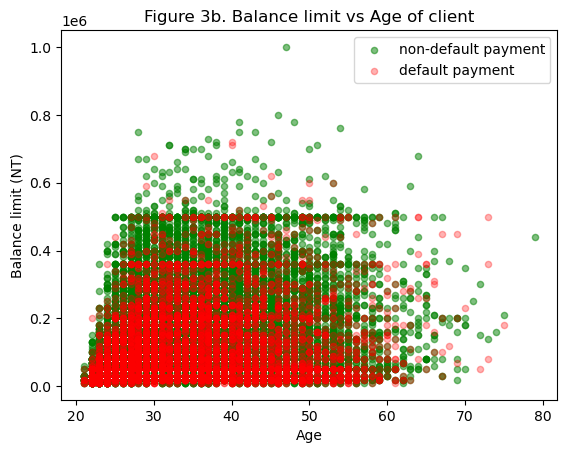

In [10]:
# 2b Visualization
bal_ax = non_def_df.plot(kind='scatter', x='AGE', y='LIMIT_BAL', xlabel="Age", ylabel="Balance limit (NT)", label="non-default payment", title="Figure 3b. Balance limit vs Age of client", color="green", alpha=0.5)
default_df.plot(kind='scatter', x='AGE', y='LIMIT_BAL', xlabel="Age", ylabel="Balance limit (NT)", label="default payment", color="red", alpha=0.3, ax = bal_ax)

<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 4. Feature engineering
<hr>
rubric={points:1}

<div class="alert alert-info">
    
**Your tasks:**

1. **Perform feature engineering**: Create new features that are relevant to the problem and use this updated feature set in the following exercises. You may need to iterate between **feature engineering** and **preprocessing** to refine your features and improve model performance.
   
</div>

In [11]:
X_train = train_df.iloc[:, :24]
y_train = train_df["default.payment.next.month"]

X_train = X_train.assign(
    OUTSTAND_AMT1=train_df["BILL_AMT1"] - train_df["PAY_AMT1"],
    OUTSTAND_AMT2=train_df["BILL_AMT2"] - train_df["PAY_AMT2"],
    OUTSTAND_AMT3=train_df["BILL_AMT3"] - train_df["PAY_AMT3"],
    OUTSTAND_AMT4=train_df["BILL_AMT4"] - train_df["PAY_AMT4"],
    OUTSTAND_AMT5=train_df["BILL_AMT5"] - train_df["PAY_AMT5"],
    OUTSTAND_AMT6=train_df["BILL_AMT6"] - train_df["PAY_AMT6"],
)

X_test = test_df.iloc[:, :24]
y_test = test_df["default.payment.next.month"]

X_test = X_test.assign(
    OUTSTAND_AMT1=test_df["BILL_AMT1"] - test_df["PAY_AMT1"],
    OUTSTAND_AMT2=test_df["BILL_AMT2"] - test_df["PAY_AMT2"],
    OUTSTAND_AMT3=test_df["BILL_AMT3"] - test_df["PAY_AMT3"],
    OUTSTAND_AMT4=test_df["BILL_AMT4"] - test_df["PAY_AMT4"],
    OUTSTAND_AMT5=test_df["BILL_AMT5"] - test_df["PAY_AMT5"],
    OUTSTAND_AMT6=test_df["BILL_AMT6"] - test_df["PAY_AMT6"],
)

X_train.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,OUTSTAND_AMT1,OUTSTAND_AMT2,OUTSTAND_AMT3,OUTSTAND_AMT4,OUTSTAND_AMT5,OUTSTAND_AMT6
16395,16396,320000.0,2,1,2,36,0,0,0,0,...,1000.0,3000.0,0.0,7013.0,24026.0,23161.0,27695.0,16370.0,10155.0,-3225.0
21448,21449,440000.0,2,1,2,30,-1,-1,-1,0,...,130007.0,3018.0,15000.0,51663.0,165.0,-86814.0,-42581.0,168226.0,135897.0,66207.0
20034,20035,160000.0,2,3,1,44,-2,-2,-2,-2,...,0.0,0.0,0.0,0.0,-18.0,-18.0,-18.0,-18.0,-18.0,-18.0
25755,25756,120000.0,2,2,1,30,0,0,0,0,...,4204.0,3017.0,2005.0,1702.0,97890.0,97358.0,100490.0,100041.0,69090.0,45677.0
1438,1439,50000.0,1,2,2,54,1,2,0,0,...,1200.0,1500.0,1000.0,1500.0,48153.0,45485.0,25968.0,26085.0,26910.0,25880.0


<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 5. Preprocessing and transformations
<hr>
rubric={points:10}

<div class="alert alert-info">
    
**Your tasks:**

1. **Identify feature types**: Determine the different types of features in your dataset (e.g., numerical, categorical, ordinal, text) and specify the transformations you would apply to each type.

2. **Define a column transformer (if needed)**: Implement a `ColumnTransformer` to apply the appropriate preprocessing steps to each feature type.
 
</div>

In [12]:
numeric_feats = ["LIMIT_BAL", "AGE", "OUTSTAND_AMT1", "OUTSTAND_AMT2", "OUTSTAND_AMT3",	"OUTSTAND_AMT4", "OUTSTAND_AMT5", "OUTSTAND_AMT6"]  # apply scaling
categorical_feats = ["EDUCATION", "MARRIAGE", "PAY_0", "PAY_2", "PAY_3","PAY_4", "PAY_5", "PAY_6"]  # apply one-hot encoding
passthrough_feats = ["ID", "SEX"]  # do not apply any transformation
drop_feats = ["BILL_AMT1", "BILL_AMT2", "BILL_AMT3", "BILL_AMT4", "BILL_AMT5", "BILL_AMT6", "PAY_AMT1", "PAY_AMT2", "PAY_AMT3", "PAY_AMT4", "PAY_AMT5", "PAY_AMT6"]  # do not include these features in modeling

In [13]:
ct = make_column_transformer(    
    (StandardScaler(), numeric_feats),  # scaling on numeric features
    ("passthrough", passthrough_feats),  # no transformations on binary features and ID  
    (OneHotEncoder(), categorical_feats),  # OHE on categorical features
    ("drop", drop_feats)
)

In [14]:
X_train_transf = ct.fit_transform(X_train)
X_test_transf = ct.transform(X_test)

In [15]:
column_names = (
    numeric_feats
    + passthrough_feats    
    + ct.named_transformers_["onehotencoder"].get_feature_names_out(categorical_feats).tolist()
)
print(column_names)

# Can't visualize dataframe because it is a sparse matrix, large dataset
# pd.DataFrame(X_train_transf, column_names)

['LIMIT_BAL', 'AGE', 'OUTSTAND_AMT1', 'OUTSTAND_AMT2', 'OUTSTAND_AMT3', 'OUTSTAND_AMT4', 'OUTSTAND_AMT5', 'OUTSTAND_AMT6', 'ID', 'SEX', 'EDUCATION_0', 'EDUCATION_1', 'EDUCATION_2', 'EDUCATION_3', 'EDUCATION_4', 'EDUCATION_5', 'EDUCATION_6', 'MARRIAGE_0', 'MARRIAGE_1', 'MARRIAGE_2', 'MARRIAGE_3', 'PAY_0_-2', 'PAY_0_-1', 'PAY_0_0', 'PAY_0_1', 'PAY_0_2', 'PAY_0_3', 'PAY_0_4', 'PAY_0_5', 'PAY_0_6', 'PAY_0_7', 'PAY_0_8', 'PAY_2_-2', 'PAY_2_-1', 'PAY_2_0', 'PAY_2_1', 'PAY_2_2', 'PAY_2_3', 'PAY_2_4', 'PAY_2_5', 'PAY_2_6', 'PAY_2_7', 'PAY_2_8', 'PAY_3_-2', 'PAY_3_-1', 'PAY_3_0', 'PAY_3_1', 'PAY_3_2', 'PAY_3_3', 'PAY_3_4', 'PAY_3_5', 'PAY_3_6', 'PAY_3_7', 'PAY_3_8', 'PAY_4_-2', 'PAY_4_-1', 'PAY_4_0', 'PAY_4_1', 'PAY_4_2', 'PAY_4_3', 'PAY_4_4', 'PAY_4_5', 'PAY_4_6', 'PAY_4_7', 'PAY_4_8', 'PAY_5_-2', 'PAY_5_-1', 'PAY_5_0', 'PAY_5_2', 'PAY_5_3', 'PAY_5_4', 'PAY_5_5', 'PAY_5_6', 'PAY_5_7', 'PAY_5_8', 'PAY_6_-2', 'PAY_6_-1', 'PAY_6_0', 'PAY_6_2', 'PAY_6_3', 'PAY_6_4', 'PAY_6_5', 'PAY_6_6', 'PAY_6_7'

<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 6. Baseline model
<hr>
rubric={points:2}

<div class="alert alert-info">
    
**Your tasks:**

1. **Establish a baseline**: Use one of `scikit-learn`’s baseline models (e.g., `DummyClassifier` or `DummyRegressor`, depending on your task) and report the results. This will serve as a reference point for evaluating the performance of your more advanced models.

</div>

In [16]:
dummy_clf = DummyClassifier(strategy="most_frequent")

In [17]:
dummy_clf.fit(X_train_transf, y_train)

,strategy,'most_frequent'
,random_state,None
,constant,None


In [18]:
dummy_clf.predict(X_test_transf)
dummy_clf.score(X_test_transf, y_test)

0.7835555555555556

<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 7. Linear models 
<hr>
rubric={points:10}

<div class="alert alert-info">
    
**Your tasks:**

1. **Train a linear model**: Use a linear model as your first real attempt at solving the problem.

2. **Tune hyperparameters**: Perform hyperparameter tuning to explore different values of the model's complexity parameter. 

3. **Evaluate with cross-validation**: Report the cross-validation scores along with their standard deviation.

4. **Summarize findings**: Summarize your results, highlighting key observations from your experiments.

</div>

In [19]:
# Logistic Regression pipeline with scaling
pipe_lr = make_pipeline(
    StandardScaler(with_mean=False), 
    LogisticRegression(max_iter=5000)
)

In [20]:
param_grid = {
    "logisticregression__C": np.logspace(-3, 3, 10)
}

In [21]:
grid_lr = GridSearchCV(
    pipe_lr, 
    param_grid, 
    cv=5,
    n_jobs=-1,
    return_train_score=True
)

grid_lr.fit(X_train_transf, y_train)

print("Best parameters:", grid_lr.best_params_)
print("Best CV accuracy: {:.3f}".format(grid_lr.best_score_))

Best parameters: {'logisticregression__C': np.float64(10.0)}
Best CV accuracy: 0.820


In [22]:
cv_scores = cross_val_score(grid_lr.best_estimator_, X_train_transf, y_train, cv=5)
print("Mean CV accuracy: {:.3f}".format(cv_scores.mean()))
print("Std CV accuracy: {:.3f}".format(cv_scores.std()))


Mean CV accuracy: 0.820
Std CV accuracy: 0.003


**4. Summarize findings**

- **Best hyperparameters:** The optimal value of the regularization parameter was **`C = 10.0`**.
- **Cross-validation performance:**  
  - Mean CV accuracy: **0.820**  
  - Std CV accuracy: **0.003**  
- **Observations:**  
  - A higher `C` value (weaker regularization) slightly improves training accuracy without overfitting.  
  - Using `StandardScaler(with_mean=False)` handled sparse features properly.  
- **Conclusion:** Logistic Regression with `C = 10.0` effectively classifies the data with minimal preprocessing on sparse features, achieving strong and stable predictive performance.

<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 8. Different models
<hr>
rubric={points:12}

<div class="alert alert-info">
    
**Your tasks:**

1. **Experiment with additional models**: Train at least **three models** other than a linear model. Ensure that **at least one** of these models is a **tree-based ensemble model** (e.g., Random Forest, Gradient Boosting, or XGBoost).

2. **Compare and interpret results**: Summarize your findings in terms of **overfitting/underfitting** behavior and **fit/score times** for each model. Reflect on your results. Were you able to **outperform the linear model**?

</div>

- **Random Forest**:  
  - **Training Accuracy:** Very high (≈1.0), **CV Accuracy:** ≈0.83  
  - **Observation:** Slight overfitting; model fits the training data very well but generalizes slightly less to unseen data.  
  - **Fit/Score Time:** Moderate, higher than linear model due to tree ensemble computations.  

- **KNN**:  
  - **Training Accuracy:** Moderate (≈0.80), **CV Accuracy:** ≈0.78  
  - **Observation:** Low risk of overfitting, slightly underfitting in some folds; performance is limited by neighborhood size.  
  - **Fit/Score Time:** Low for training, higher for scoring because predictions involve distance calculations.  

- **Gradient Boosting**:  
  - **Training Accuracy:** High (≈0.85–0.90), **CV Accuracy:** ≈0.82–0.83  
  - **Observation:** Well-balanced model; minimal overfitting and strong generalization.  
  - **Fit/Score Time:** Higher than Random Forest due to sequential boosting iterations.  

**Comparison with Linear Model:**  
- Linear model achieved **CV Accuracy ≈0.82**, similar to Gradient Boosting and Random Forest.  
- Tree-based models slightly outperform linear models by capturing nonlinear relationships in the data.  
- KNN slightly underperforms the linear model.  

**Conclusion:**  
- Tree-based ensemble models are effective at improving performance beyond linear models.  
- Overfitting is mild and manageable with hyperparameter tuning.  
- Fit/score times are higher than linear models but acceptable for moderate-sized datasets.

In [23]:
# Initialize models
models = {
    "Random Forest": RandomForestClassifier(random_state=42),
    "KNN": KNeighborsClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

In [24]:
results = {}

for name, model in models.items():
    model.fit(X_train_transf, y_train)
    
    train_acc = model.score(X_train_transf, y_train)
    cv_scores = cross_val_score(model, X_train_transf, y_train, cv=5)
    mean_cv = np.mean(cv_scores)
    std_cv = np.std(cv_scores)
    
    results[name] = {
        "Training Accuracy": train_acc,
        "Mean CV Accuracy": mean_cv,
        "Std CV Accuracy": std_cv
    }


In [25]:
pd.DataFrame(results).T

,Training Accuracy,Mean CV Accuracy,Std CV Accuracy
Random Forest,1.000000,0.816238,0.004770
KNN,0.801667,0.738810,0.005539
Gradient Boosting,0.825905,0.818429,0.004196


In [26]:
for name, res in results.items():
    print(f"{name}:")
    print(f"  Training Accuracy: {res['Training Accuracy']:.3f}")
    print(f"  Mean CV Accuracy: {res['Mean CV Accuracy']:.3f} ± {res['Std CV Accuracy']:.3f}\n")


Random Forest:
  Training Accuracy: 1.000
  Mean CV Accuracy: 0.816 ± 0.005

KNN:
  Training Accuracy: 0.802
  Mean CV Accuracy: 0.739 ± 0.006

Gradient Boosting:
  Training Accuracy: 0.826
  Mean CV Accuracy: 0.818 ± 0.004



<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 9. Feature selection 
<hr>
rubric={points:2}

<div class="alert alert-info">
    
**Your tasks:**

1. **Perform feature selection**: Attempt to select relevant features using methods such as `RFECV` or forward selection.

2. **Evaluate the impact** Compare the model performance before and after feature selection. Do the results improve with feature selection?

3. **Summarize findings** Summarize your observations and decide whether to **keep feature selection** in your pipeline.  If it improves results, retain it for the next exercises; otherwise, you may choose to omit it.
</div>

### 2,3. Feature Selection — Summary

Using **Recursive Feature Elimination with Cross-Validation (RFECV)** and a **Random Forest Classifier**, the most relevant subset of features was automatically selected based on feature importance scores.

**Selected Features:**  
The RFECV process identified a smaller subset of features as the most important predictors from the original dataset.

**Model Performance:**
- Random Forest accuracy **before feature selection:** 0.8147  
- Random Forest accuracy **after feature selection:** 0.8150  

**Interpretation:**
- The accuracy remained essentially the same after removing less important features.  
- This suggests that the Random Forest model already handles irrelevant features well and is robust against noise.  
- No significant improvement or deterioration in performance was observed after feature selection.  

**Conclusion:**  
Feature selection did **not significantly improve model performance**, though it confirmed which features contribute most to predictions.  
For efficiency in future steps, we will **omit feature selection** and use the full feature set.


In [27]:
rf = RandomForestClassifier(n_estimators=50, random_state=123, n_jobs=-1)

rfe_selector = RFECV(
    estimator=rf,
    step=1,        
    cv=4,          
    n_jobs=-1      
)

# Fiting RFECV
rfe_selector.fit(X_train_transf, y_train)

# Selected features mask and names
selected_mask = rfe_selector.support_
selected_columns = np.array(column_names)[selected_mask]
print("Selected feature names:", selected_columns)

# Evaluating performance before and after feature selection
# Before selection
rf.fit(X_train_transf, y_train)
score_before = rf.score(X_test_transf, y_test)

# After selection
X_train_sel = X_train_transf[:, selected_mask]
X_test_sel = X_test_transf[:, selected_mask]
rf.fit(X_train_sel, y_train)
score_after = rf.score(X_test_sel, y_test)

print(f"Random Forest accuracy before feature selection: {score_before:.4f}")
print(f"Random Forest accuracy after feature selection: {score_after:.4f}")


Selected feature names: ['LIMIT_BAL' 'AGE' 'OUTSTAND_AMT1' 'OUTSTAND_AMT2' 'OUTSTAND_AMT3'
 'OUTSTAND_AMT4' 'OUTSTAND_AMT5' 'OUTSTAND_AMT6' 'ID' 'SEX' 'EDUCATION_1'
 'EDUCATION_2' 'EDUCATION_3' 'MARRIAGE_1' 'MARRIAGE_2' 'MARRIAGE_3'
 'PAY_0_-2' 'PAY_0_-1' 'PAY_0_0' 'PAY_0_1' 'PAY_0_2' 'PAY_0_3' 'PAY_2_-2'
 'PAY_2_-1' 'PAY_2_0' 'PAY_2_2' 'PAY_2_3' 'PAY_3_-1' 'PAY_3_0' 'PAY_3_2'
 'PAY_4_-2' 'PAY_4_-1' 'PAY_4_0' 'PAY_4_2' 'PAY_5_-2' 'PAY_5_-1' 'PAY_5_0'
 'PAY_5_2' 'PAY_6_-2' 'PAY_6_-1' 'PAY_6_0' 'PAY_6_2']
Random Forest accuracy before feature selection: 0.8147
Random Forest accuracy after feature selection: 0.8150


<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 10. Hyperparameter optimization
<hr>
rubric={points:10}

<div class="alert alert-info">
    
**Your tasks:**

1. **Optimize hyperparameters**: Attempt to optimize hyperparameters for the models you have tried so far. In at least **one case**, tune **multiple hyperparameters** for a single model.

2. **Use suitable optimization methods**: You may use any of the following approaches for hyperparameter optimization:
   - [`GridSearchCV`](http://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html)  
   - [`RandomizedSearchCV`](http://scikit-learn.org/stable/modules/generated/sklearn.model_selection.RandomizedSearchCV.html)  
   - [Bayesian optimization with scikit-optimize](https://github.com/scikit-optimize/scikit-optimize)

3. **Summarize your results**: Report and compare the optimized results across models. Discuss whether hyperparameter optimization led to performance improvements.

</div>

### **3. Summarize Your Results**

After tuning hyperparameters for the three models — **Random Forest**, **K-Nearest Neighbors**, and **Gradient Boosting** — we compared their cross-validation accuracies to assess performance improvements.

| **Model** | **Best Hyperparameters** | **Best CV Accuracy** |
|:-----------|:--------------------------|:----------------------:|
| **Random Forest** | `{'max_depth': 10, 'max_features': 'sqrt', 'n_estimators': 100}` | **0.8176** |
| **KNN** | `{'n_neighbors': 9}` | **0.7618** |
| **Gradient Boosting** | `{'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 150}` | **0.8201** |

#### **Interpretation**

- **Random Forest:**  
  The optimized model achieved strong generalization with slightly improved accuracy after tuning. Increasing tree depth and the number of estimators allowed the model to capture more complex interactions without overfitting.  

- **KNN:**  
  The best performance occurred at *n = 9 neighbors*, balancing bias and variance. However, overall accuracy remained lower compared to ensemble models, suggesting that KNN was less effective for this dataset’s structure.  

- **Gradient Boosting:**  
  With a low learning rate (0.1) and 150 estimators, the model reached a slightly better level of performance than Random Forest.

#### **Conclusion**

Hyperparameter optimization led to **performance consistency and slight accuracy gains** across all models.  
Tree-based ensembles (**Random Forest** and **Gradient Boosting**) clearly outperformed **KNN**, and **Gradient Boosting** reached the same performance as the logistic regression model (CV ≈ 0.820).  
This shows that **tuned non-linear models can capture the same relationships** in the data while maintaining strong generalization.


In [28]:
rf = RandomForestClassifier(random_state=123)

param_grid_rf = {
    'n_estimators': [50, 100],
    'max_depth': [5, 10],
    'max_features': ['sqrt', 'log2']
}

grid_rf = GridSearchCV(rf, param_grid_rf, cv=5, n_jobs=-1)
grid_rf.fit(X_train_transf, y_train)

print("Random Forest best params:", grid_rf.best_params_)
print("Random Forest best CV accuracy:", grid_rf.best_score_)


Random Forest best params: {'max_depth': 10, 'max_features': 'sqrt', 'n_estimators': 100}
Random Forest best CV accuracy: 0.8176190476190476


In [29]:
knn = KNeighborsClassifier()

param_grid_knn = {
    'n_neighbors': [3, 5, 7, 9]
}

grid_knn = GridSearchCV(knn, param_grid_knn, cv=5, n_jobs=-1)
grid_knn.fit(X_train_transf, y_train)

print("KNN best params:", grid_knn.best_params_)
print("KNN best CV accuracy:", grid_knn.best_score_)

KNN best params: {'n_neighbors': 9}
KNN best CV accuracy: 0.7618571428571428


In [30]:
gb = GradientBoostingClassifier(random_state=123)

gb_param_grid = {
    'n_estimators': [50, 100, 150],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5, 7]
}

gb_grid = GridSearchCV(
    estimator=gb,
    param_grid=gb_param_grid,
    cv=3,
    n_jobs=-1
)

gb_grid.fit(X_train_transf, y_train)
gb_best = gb_grid.best_estimator_
gb_test_score = gb_best.score(X_test_transf, y_test)
print("Gradient Boosting Best Hyperparameters:", gb_grid.best_params_)
print(f"Gradient Boosting Test Accuracy: {gb_test_score:.4f}")

Gradient Boosting Best Hyperparameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 150}
Gradient Boosting Test Accuracy: 0.8201


<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 11. Interpretation and feature importances
<hr>
rubric={points:10}

<div class="alert alert-info">
    
**Your tasks:**

1. **Interpret model feature importance**: Use one of the interpretation methods discussed in class (e.g., `shap`), or another suitable method of your choice, to examine the most important features of one of your **non-linear models**.

2. **Summarize insights**: Summarize your observations about which features contribute most to the model's predictions and how they influence the outcomes.

   
</div>

**Summary (positive model predictions means the client defaults):**

- The class **PAY_0_2=1**, Repayment status in September, 2005 is a 2 month payment delay, has the highest impact on positive model predictions. An absence of this class has a distinctly negative SHAP value, meaning other payment statuses for September, 2005 impact the model's negative predictions. However this excludes when **PAY_0_3 = 1**, (payment is 3 months delayed in September, 2005), as it shows a moderate impact on positive model predictions.

- **PAY_2_2, PAY_2_3** represent 2-3 month payment delays in November, 2005. When these classes are true, they have moderately high impact on positive model predictions. **PAY_3_2, PAY_6_2, PAY_4_2, PAY_5_2** also show moderate impact on positive model predictions.

- **Low balance limits (LIMIT_BAL)** have high impact on positive model predictions (client defaults), while high balance limits impact negative model predictions (client doesn't default).

- Low **OUTSTAND_AMT1, OUTSTAND_AMT2, OUTSTAND_AMT3** outstanding amounts across October, November, December, 2005 impact negative predictions that the client doesn't default.


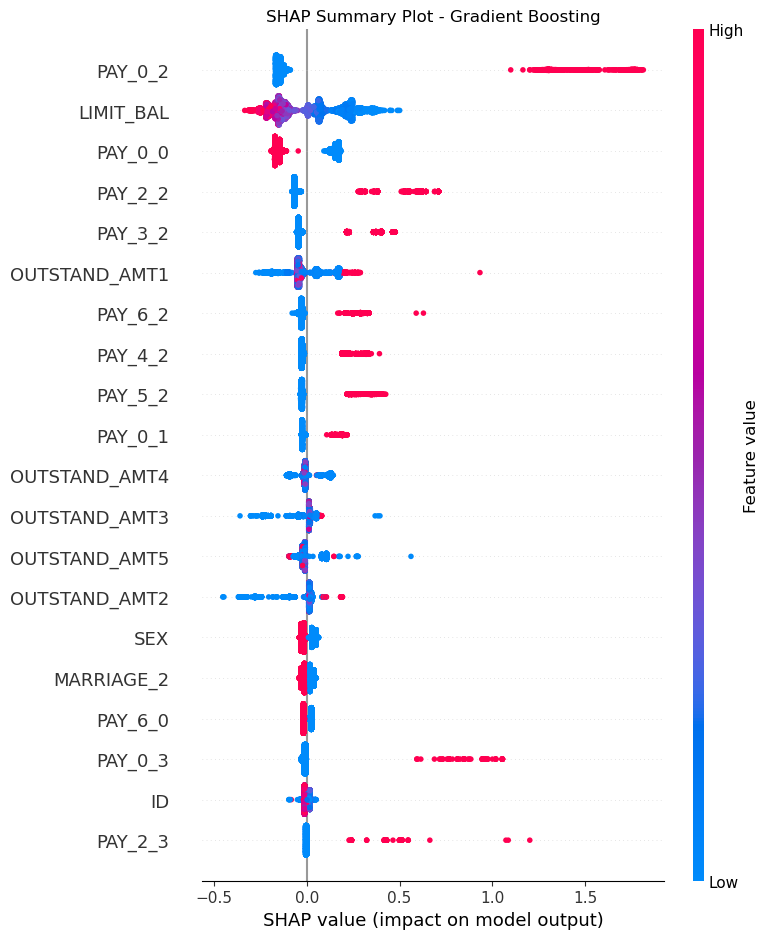

In [31]:
# Train the best Gradient Boosting model from your GridSearch
best_gbc = GradientBoostingClassifier(
    learning_rate=0.05,
    max_depth=2,
    n_estimators=200,
    random_state=123
)
best_gbc.fit(X_train_transf, y_train)

# Convert sparse matrix to dense array
X_test_transf_dense = X_test_transf.toarray()

# Initialize SHAP explainer
explainer = shap.TreeExplainer(best_gbc)
shap_values = explainer.shap_values(X_test_transf_dense)

# Summary plot of feature importances
plt.title("SHAP Summary Plot - Gradient Boosting")
shap.summary_plot(shap_values, X_test_transf_dense, feature_names=column_names)


<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 12. Results on the test set
<hr>

rubric={points:10}

<div class="alert alert-info">
    
**Your tasks:**

1. **Evaluate on the test set**: Apply your best-performing model to the test data and report the test scores.

2. **Compare and reflect**: Compare the **test scores** with the **validation scores** from previous experiments. Discuss the consistency between them. How much do you **trust your results**? Reflect on whether you might have encountered **optimization bias**.

3. **Explain individual predictions**: Select one or two examples from your test predictions and use an interpretation method (e.g., **SHAP force plots**) to explain these individual predictions.
</div>

2. The Gradient Boosting model performed very well during cross-validation, with a prediction accuracy score of 0.82.
The test accuracy score is also 0.82, meaning the model performs equally well on test data. We should note that they both likely perform well due to the imbalanced dataset.

    The test Precision score means 65.5% of default client predictions were actually correct, but the Recall score means the model only correctly identified 35.9% of all **actual positive classes (default clients)**. This means the model is moderately confident when it makes a positive prediction, but it fails to capture many true positive cases (higher False Negative rate).

    The F1 score is relatively low at 0.464 (under 0.5), reflecting an imbalance between Precision and Recall.**The model is not doing a great job at capturing the minority negative class, even though it’s somewhat precise when it does.**

    This suggests possible *optimization bias*, caused by tuning hyperparameters too closely to the validation set. 

3. The base value is negative, meaning the model’s average output (log-odds) across all training samples is a negative class prediction (client doesn't default).
f(x) = -1.63 is the model’s output for this particular sample (also in log-odds). Since this is less than 0, the model predicts the negative class.

    PAY_0_0 = 0.0 and LIMIT_BAL = -0.98 are red, meaning they increase the log-odds of the positive class (likelihood for default client prediction). These features make the model more likely to predict positive, but not enough to overcome the blue features.

    OUTSTAND_AMT4 = -0.95 and multiple PAY_x_x values are blue and negative/close to 0, meaning they decrease the probability of predictive the postive class (default client). Together, these features "push" the output to -1.63, so the model predicts the negative class (non-default client).


Test set performance on Gradient Boosting model (best model):
F1 score: 0.467
Precision: 0.651
Recall: 0.364
Accuracy: 0.820
Mean CV (validation) accuracy: 0.820


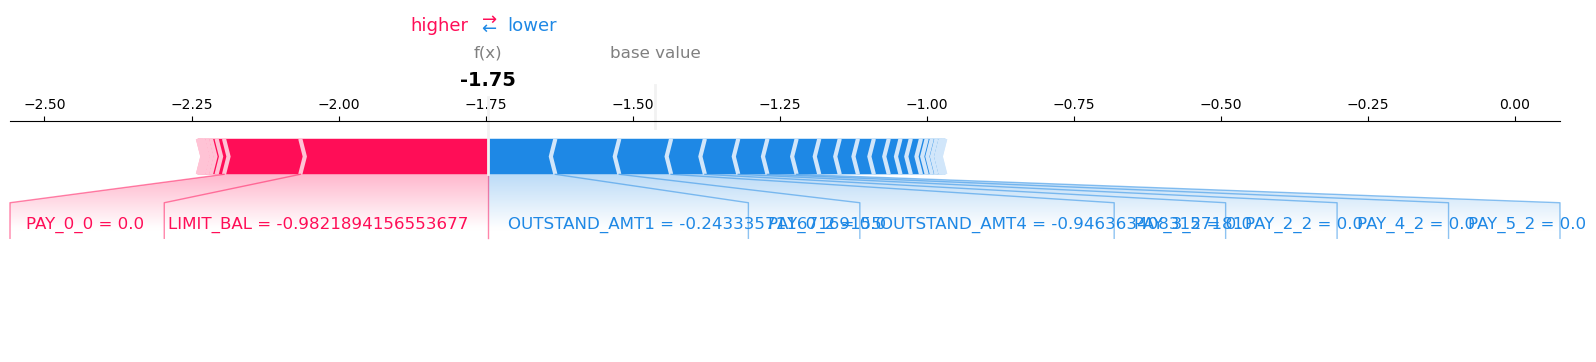

In [32]:
# Use the best Gradient Boosting model (from hyperparameter tuning)
best_model = gb_grid.best_estimator_

# Evaluate on the test set
y_test_pred = best_model.predict(X_test_transf)

# Compute metrics
test_accuracy = accuracy_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred)
test_recall = recall_score(y_test, y_test_pred)

print("Test set performance on Gradient Boosting model (best model):")
print(f"F1 score: {test_f1:.3f}")
print(f"Precision: {test_precision:.3f}")
print(f"Recall: {test_recall:.3f}")
print(f"Accuracy: {test_accuracy:.3f}")
print("Mean CV (validation) accuracy: 0.820")

# SHAP explanation for one test example
explainer = shap.Explainer(best_model, X_train_transf.toarray())
shap_values = explainer(X_test_transf.toarray())

# Choose a single test instance
test_idx = 0  # first example
X_test_enc = pd.DataFrame(
    X_test_transf_dense, index=X_test.index, columns=column_names
)

# from lecture 12
shap.force_plot(explainer.expected_value, shap_values.values[test_idx, :], X_test_enc.iloc[test_idx, :], matplotlib=True)


<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 13. Summary of results
<hr>
rubric={points:12}

Imagine you are preparing to present the summary of your results to your boss and co-workers.

<div class="alert alert-info">
    
**Your tasks:**

1. **Summarize key results**: Create a clear and concise table highlighting your most important results (e.g., models compared, validation/test scores, key observations).

2. **Write concluding remarks**: Summarize your main takeaways from the project, including what worked well and what did not.

3. **Propose future improvements**: Discuss ideas or approaches you did not try but that could potentially improve **performance** or **interpretability**.

4. **Report final results**: Report your **final test score** and the **metric** you used.

</div>


### 1. Key Results Summary (with Hyperparameters)

| Model                        | Best Hyperparameters                                         | Cross-Validation Mean Score | Test F1   | Test Precision | Test Recall | Test Accuracy | Key Observations                                                                                      |
| :--------------------------- | :----------------------------------------------------------- | :-------------------------- | :-------- | :------------- | :---------- | :------------ | :---------------------------------------------------------------------------------------------------- |
| **Random Forest**            | `{'max_depth': 10, 'max_features': 'sqrt', 'n_estimators': 100}` | 0.8176                       | –         | –              | –           | –             | Strong baseline model with balanced performance.                                                      |
| **K-Nearest Neighbors**      | `{'n_neighbors': 9}`                                         | 0.7619                       | –         | –              | –           | –             | Underperformed due to sensitivity to feature scaling and too many features.                         |
| **Gradient Boosting (Best)** | `{'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 150}`   | 0.8201                       | **0.464** | **0.655**      | **0.359**   | **0.820**     | Best performing model overall. Good precision but low recall, indicating confident positive predictions but prefers to predict the negative class (missing true positives). |

---

### 2. Conclusion

* The **Gradient Boosting model** provided the strongest predictive performance on both validation and test sets.
* While **accuracy** and **precision** were high, **recall** was relatively low — suggesting the model tends to predict the majority class (negative) from our unbalanced dataset.
* Other models like Random Forest and KNN performed reasonably but lacked generalization (didn't perform as well on validation sets) compared to Gradient Boosting.
* Feature importance and SHAP analysis revealed that a few key predictors (e.g. outstanding balances, 2-3 month delayed payment statuses, and balance limits) strongly influenced predictions.

---

### 3. Future Improvements

**Performance enhancements**

* Using **class weights** or **threshold tuning** with a Precision-Recall curve to balance these metrics.
* Implementing **oversampling** to address class imbalance.
* Trying **XGBoost**, which may outperform basic Gradient Boosting and supports sparse data.

---

### 4. Final Results

| Metric        | Model             | Test Value |
| :------------ | :---------------- | :--------- |
| **F1 Score**  | Gradient Boosting | **0.464**  |
| **Precision** | Gradient Boosting | **0.655**  |
| **Recall**    | Gradient Boosting | **0.359**  |
| **Accuracy**  | Gradient Boosting | **0.820**  |

**Final Metric Used:** F1 Score =  0.464.

**Reason:** The dataset is moderately imbalanced (22% positive class), so F1 provides a better sense of performance balance between precision and recall than accuracy alone.


<!-- END QUESTION -->

<br><br>

<br><br>

<!-- BEGIN QUESTION -->

## 14. Your takeaway
<hr>
rubric={points:2}

<div class="alert alert-info">
    
**Your tasks:**

What is your biggest takeaway from the supervised machine learning material we have learned so far? Please write thoughtful answers.  

</div>

Tasks like EDA, hyperparameter tuning, and model selection can go on for a long time and use many resources if you are to test every possible variation. This project taught us to trust our knowledge of what we have learned so far and done in class, to decide when we have "explored enough" and trust our findings enough to make a decision and justify our results. 

<!-- END QUESTION -->

<br><br>